<div style="background-color: #E8F8F5; padding: 20px; border: 2px solid #1ABC9C; border-radius: 10px;">
    VISUALIZACIONES MATPLOTLIB Y SEABORN
</div>



![texto alternativo](video_joan.png)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px



---
### RESUMEN

BARRAS
DataFrame.plot.bar(x=Ninguno, y=Ninguno, color=Ninguno, **kwargs)

HISTOGRAMA
DataFrame.plot.hist(by=Ninguno, contenedores=10, **kwargs)

SCATTER
DataFrame.plot.scatter(x, y, s=Ninguno, c=Ninguno, **kwargs)

BOXPLOT
DataFrame.plot.box(by=Ninguno, **kwargs)

ORDENAR
EJE X ES CERO
DataFrame.sort_values(por, *, eje=0, ascendente=Verdadero, en situ=Falso, tipo='quicksort', na_position='last', ignore_index=Falso, clave=Ninguno)
SORTED
---

In [3]:
# Carga del dataset de ejemplo 'tips' (propinas)
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



<div style="background-color: #FADBD8; padding: 30px;">
    1 CATEGORICA
</div>




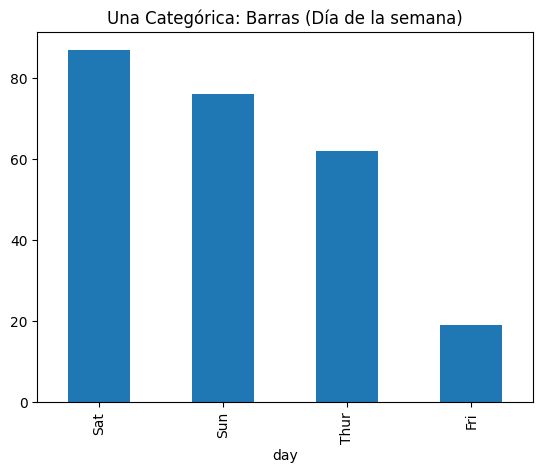

In [25]:
#MATPLOTLIB PYPLOT
# Se usa value_counts() OSEA EL RECUENTO para obtener el recuento antes de graficar
# Angulo que empiece en 90

tabla = df["day"].value_counts().sort_values(ascending=False)
tabla.plot.bar()
plt.title("Una Categórica: Barras (Día de la semana)")
plt.show()



<Axes: >

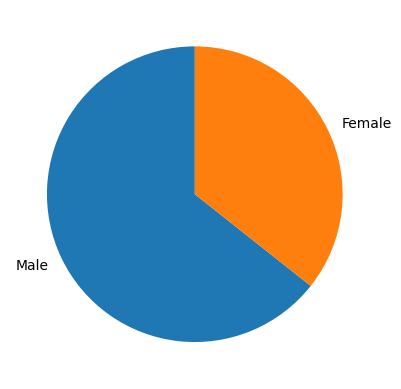

In [5]:
#MATPLOTLIB PYPLOT
# Se usa value_counts() OSEA EL RECUENTO para obtener el recuento antes de graficar
# Angulo que empiece en 90

tabla = df['sex'].value_counts()
tabla.plot.pie(startangle=90)


<div style="background-color: #FADBD8; padding: 30px;">
    1 NUMERICA
</div>





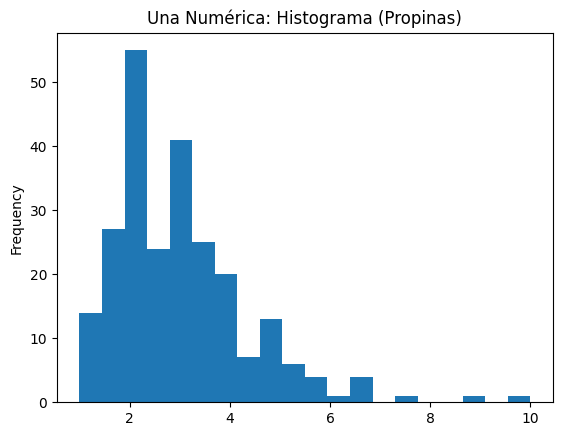

In [6]:
# Histograma (frecuencia por rangos/bins)

df['tip'].plot.hist(bins=20)
plt.title("Una Numérica: Histograma (Propinas)")
plt.show();

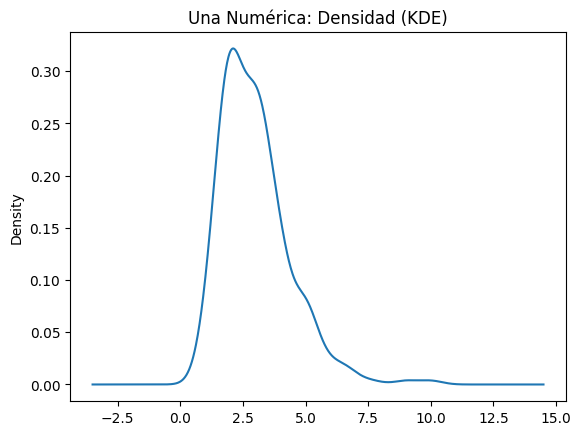

In [27]:
# Gráfico de Densidad (KDE)
plt.figure()
df['tip'].plot.kde()
plt.title("Una Numérica: Densidad (KDE)")
plt.show()



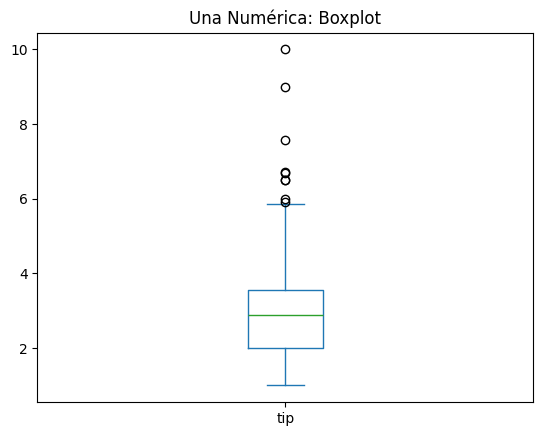

In [9]:
# Boxplot (Diagrama de caja y bigotes para estadística)
df['tip'].plot.box()
plt.title("Una Numérica: Boxplot")
plt.show();


<div style="background-color: #FADBD8; padding: 30px;">
    2 CATEGORICAS
</div>




In [10]:
# Se recomienda usar crosstab para crear una tabla de doble entrada
# podemos trasponer columnas por filas
pd.crosstab(df['sex'], df['day'])

day,Thur,Fri,Sat,Sun
sex,,,,
Male,30,10,59,58
Female,32,9,28,18


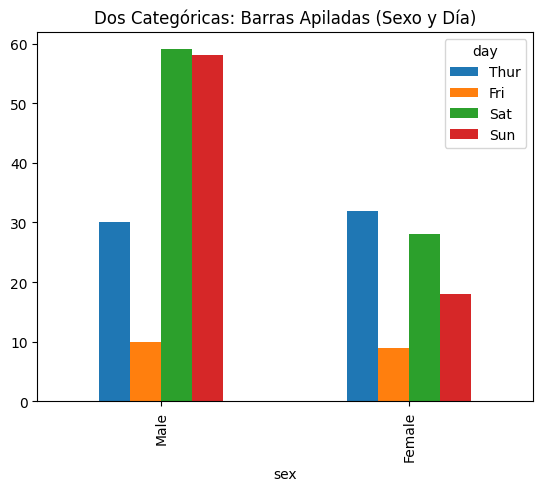

In [11]:
pd.crosstab(df['sex'], df['day']).plot.bar()
plt.title("Dos Categóricas: Barras Apiladas (Sexo y Día)")
plt.show()

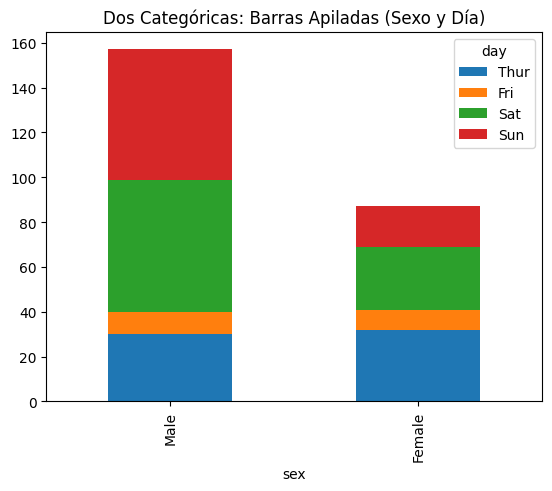

In [12]:
#BARRAS APILADAS ES CON PARAMETRO STACKED = TRUE HABRIA QUE NORMALIZAR LA TABLA INICIAL
pd.crosstab(df['sex'], df['day']).plot.bar(stacked=True)
plt.title("Dos Categóricas: Barras Apiladas (Sexo y Día)")
plt.show()


<div style="background-color: #FADBD8; padding: 30px;">
    2 NUMERICAS
</div>





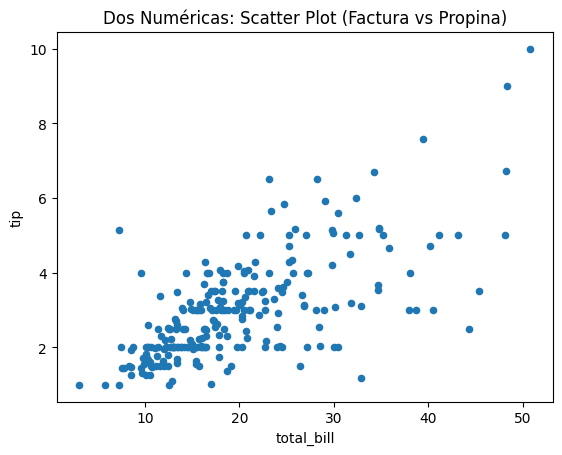

In [13]:
# Scatter Plot sencillo con Matplotlib
df.plot.scatter(x='total_bill', y='tip')
plt.title("Dos Numéricas: Scatter Plot (Factura vs Propina)")
plt.show()

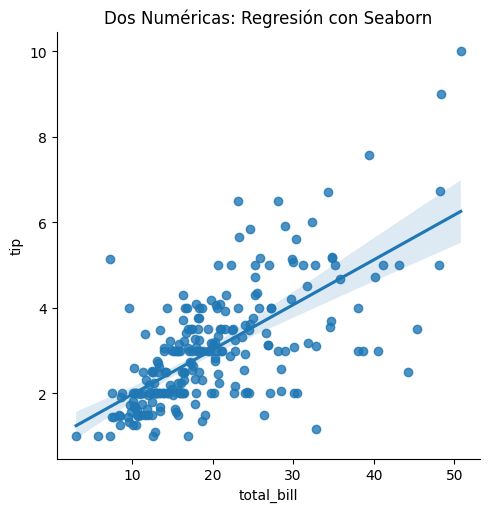

In [14]:
# Scatter Plot con recta de regresión e intervalo de confianza usando Seaborn
sns.lmplot(data=df, x='total_bill', y='tip')
plt.title("Dos Numéricas: Regresión con Seaborn")
plt.show()


<div style="background-color: #FADBD8; padding: 30px;">
    1 NUMERICA Y 1 CAT
</div>





<div style="background-color: #FFF9C4; padding: 15px; border-left: 6px solid #FBC02D;">
    SIEMPRE GROUP BY:PROMEDIO DE PROPINA (EJE Y), AGRUPO POR SEXO, COJO LA PROPINA Y LA MEDIA
</div>



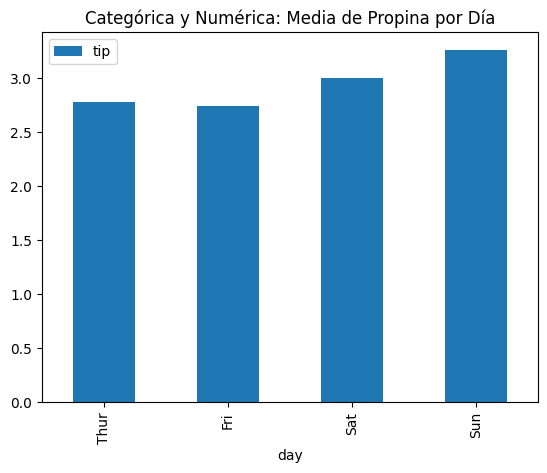

In [15]:
# Barras de promedio (ej. media de propina por día)

# tip es la numerica, dia es la cat
# observed =false si no quiero leyenda de labels

df.groupby("day")[['tip']].mean().plot.bar()
plt.title("Categórica y Numérica: Media de Propina por Día")
plt.show()

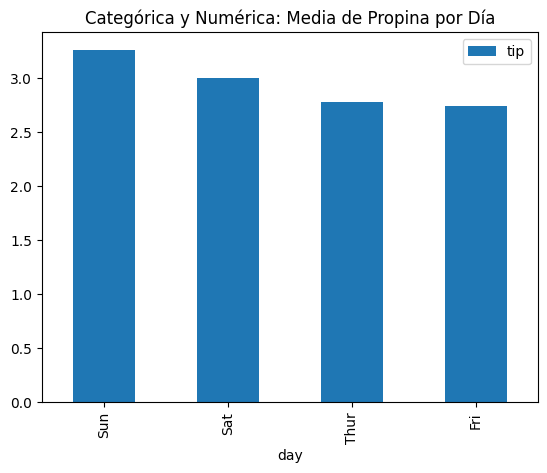

In [26]:
# ORDENADOS DE MAYOR A MENOR

df.groupby("day")[["tip"]].mean().sort_values("tip", ascending=False).plot.bar()

plt.title("Categórica y Numérica: Media de Propina por Día")
plt.show()


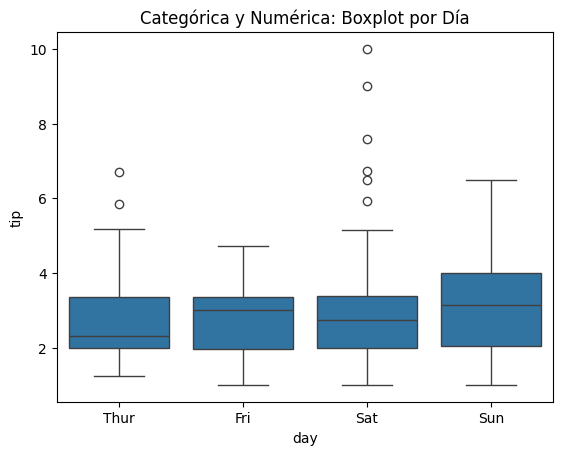

In [16]:
# Boxplot comparativo (Distribución de propinas por día de la semana) sin group by
sns.boxplot(data=df, x='day', y='tip')
plt.title("Categórica y Numérica: Boxplot por Día")
plt.show()


<div style="background-color: #FADBD8; padding: 30px;">
    MAS DE 2 VARS
</div>





----
### 1 NUM + 2 CAT
----

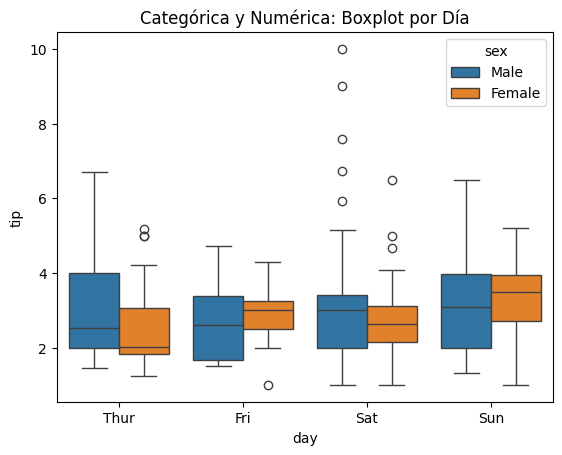

In [17]:
# BOXPLOT AÑADIENDO EL DESGLOSE POR SEXO ES CON hue = sex

sns.boxplot(df, x='day', y='tip', hue = "sex")
plt.title("Categórica y Numérica: Boxplot por Día")
plt.show()

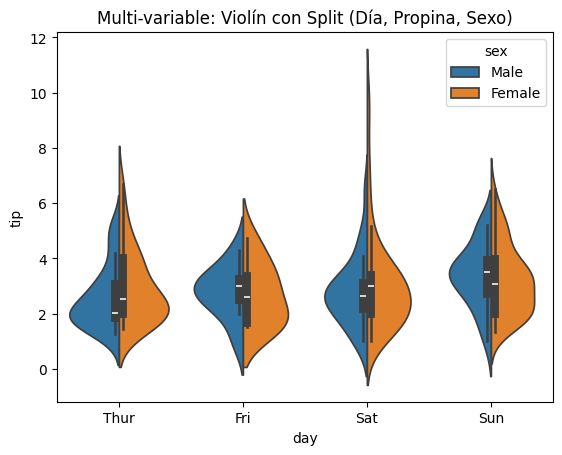

In [18]:

# Violín Plot con 'split' para comparar una tercera variable (sexo)

sns.violinplot(df, x='day', y='tip', hue='sex', split=True)
plt.title("Multi-variable: Violín con Split (Día, Propina, Sexo)")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

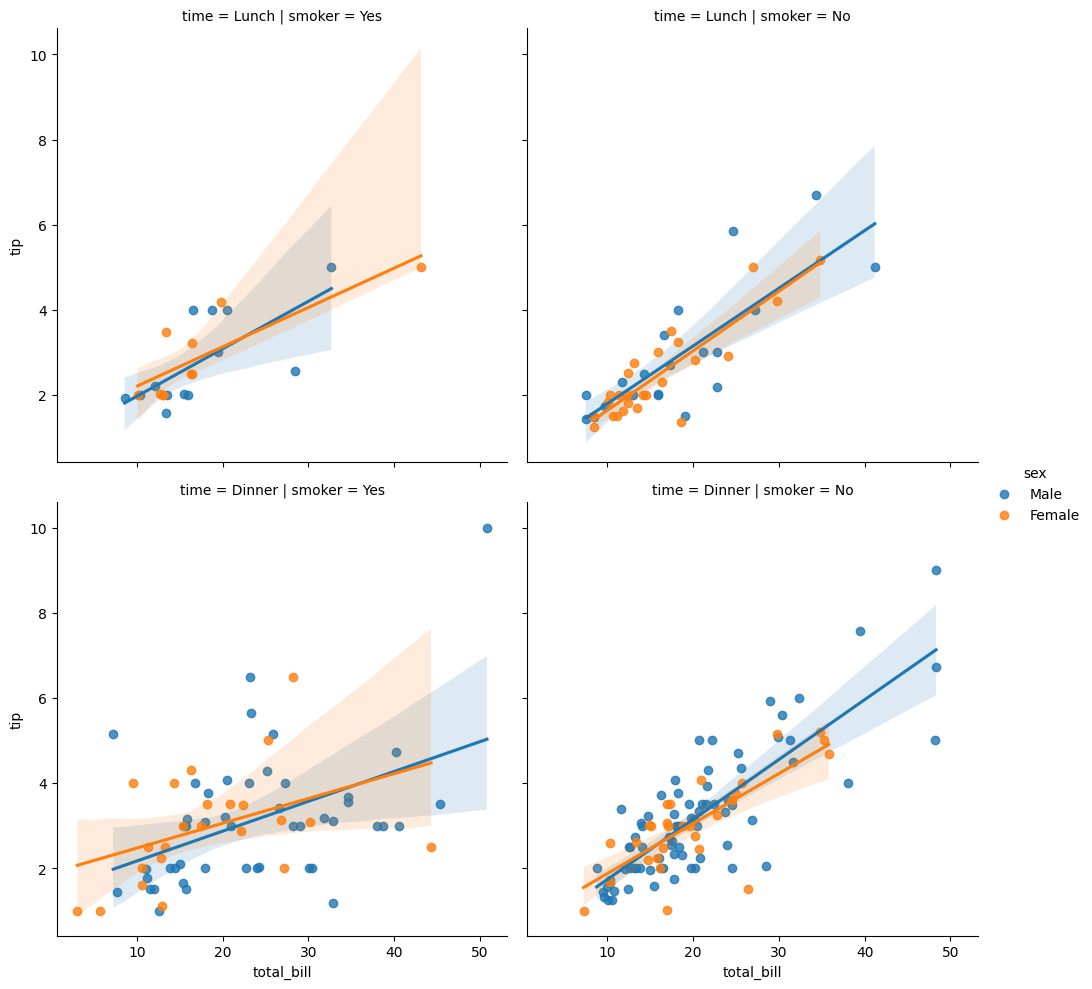

In [19]:
# Relplot (Scatter avanzado) usando color, columnas, filas y tamaño
# Representa hasta 6 variables: x, y, color (hue), columnas, filas y tamaño (size)
sns.lmplot(
    data=df, x='total_bill', y='tip',
    hue='sex', col='smoker', row = "time"
)
plt.show

-----------------------------------------------------------------------------
### GRÁFICO INTERACTIVO CON PLOTLY
-----------------------------------------------------------------------------

In [20]:
# Scatter interactivo con color y símbolos distintos
fig = px.scatter(
    df, x='total_bill', y='tip',
    color='sex', symbol='smoker',
    title="Gráfico Interactivo con Plotly"
)
fig.show()

### Notas sobre el código basado en las fuentes:
*   **Variables Categóricas:** Se enfatiza que las barras son la opción más versátil. El gráfico de sectores solo se recomienda cuando hay muy pocos grupos (máximo 2 o 3).
*   **Diferencia clave:** Las barras se usan para categorías, mientras que los histogramas son para variables numéricas continuas (sin separación entre bloques).
*   **Visualización Estadística:** Se introducen los **Boxplots** y **Violines** para ver distribuciones y cuartiles de forma más técnica.
*   **Interactividad:** Al final se utiliza **Plotly** para crear gráficos que permiten hacer zoom y explorar los datos de forma dinámica.